In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import joblib

# Load your trained models and asset list
rf_reg  = joblib.load("rfr.pkl")
xgb_reg = joblib.load("xgbr.pkl")
rf_cls  = joblib.load("rfc.pkl")
xgb_cls = joblib.load("xgbc.pkl")
returns_train = joblib.load("Returns.pkl")   # to get column order
tickers = list(returns_train.columns)

# Pull a period NOT used in training (adjust dates to whatever
# range you trained on, e.g. if training used 2015-2025, use
# a genuinely later window; here using the most recent 6 months)
recent_data = yf.download(
    tickers, start="2026-01-01", end="2026-06-30", auto_adjust=True
)
recent_close = recent_data["Close"].dropna()
recent_returns = recent_close.pct_change().dropna()[tickers]  # enforce column order

# Re-use your existing weight generator
def generate_portfolio():
    while True:
        w = np.random.dirichlet(np.ones(7))
        if w[0] <= 0.10 and w[1] <= 0.20 and w[4] <= 0.20:
            return w

n_test = 1000
records = []

for _ in range(n_test):
    w = generate_portfolio()
    actual_vol = recent_returns.dot(w).std() * np.sqrt(252)

    features = pd.DataFrame([w], columns=tickers)
    rf_pred  = rf_reg.predict(features)[0]
    xgb_pred = xgb_reg.predict(features)[0]

    records.append({
        "actual_vol": actual_vol,
        "rf_pred": rf_pred,
        "xgb_pred": xgb_pred,
        "rf_abs_err": abs(actual_vol - rf_pred),
        "xgb_abs_err": abs(actual_vol - xgb_pred),
    })

results = pd.DataFrame(records)
print("Mean absolute error (RF)  vs real recent data:", results["rf_abs_err"].mean())
print("Mean absolute error (XGB) vs real recent data:", results["xgb_abs_err"].mean())

joblib.dump(results, "out_of_sample_validation.pkl")

[*********************100%***********************]  7 of 7 completed
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\threading.py:297: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000236D0521D50>
  self._waiters = _deque()
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\threading.py:297: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000236D0522890>
  self._waiters = _deque()
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\threading.py:297: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000236D0523D30>
  self._waiters = _deque()
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\threading.py:297: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000236D3694130>
  self._waiters = _deque()
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\threading.py:297: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000236D3694220

Mean absolute error (RF)  vs real recent data: 0.03057468050884337
Mean absolute error (XGB) vs real recent data: 0.029544098375654103


['out_of_sample_validation.pkl']

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_fontconfig_pattern.py:64: DeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_fontconfig_pattern.py:85: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_fontconfig_pattern.py:89: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_mathtext.py:45: DeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'parseString'

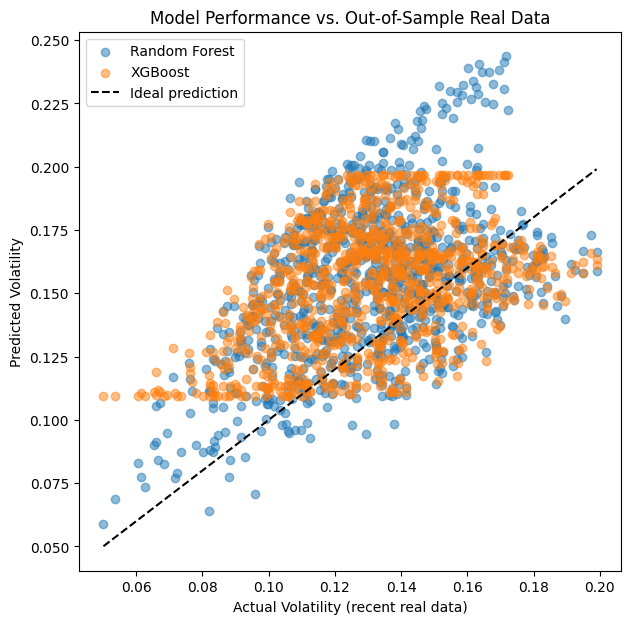

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(results["actual_vol"], results["rf_pred"], alpha=0.5, label="Random Forest")
plt.scatter(results["actual_vol"], results["xgb_pred"], alpha=0.5, label="XGBoost")
lims = [results["actual_vol"].min(), results["actual_vol"].max()]
plt.plot(lims, lims, "k--", label="Ideal prediction")
plt.xlabel("Actual Volatility (recent real data)")
plt.ylabel("Predicted Volatility")
plt.title("Model Performance vs. Out-of-Sample Real Data")
plt.legend()
plt.show()

To evaluate generalization beyond the training distribution, 1,000 fresh random portfolios were generated and evaluated against actual realized volatility computed from asset prices in a period not used during training (Jan–Jun 2026). This tests whether the model has learned a genuinely transferable relationship rather than only memorizing the training-period covariance structure, following the validation approach of Rathi et al. (2024)

In [4]:
sample_table = results.sample(5, random_state=42)[["actual_vol", "rf_pred", "xgb_pred"]]
sample_table.columns = ["Actual Volatility", "RF Predicted", "XGB Predicted"]
sample_table = (sample_table * 100).round(2)  # convert to %
print(sample_table.to_string(index=False))

 Actual Volatility  RF Predicted  XGB Predicted
             13.81         14.47          14.63
             13.83         13.82          14.01
             14.36         14.33          14.51
             13.96         15.57          15.91
             11.19         16.13          16.59
